# Import required libraries

In [1]:
pip install fasttext

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import fasttext

In [3]:
df = pd.read_csv('/content/ecommerce_dataset.csv')
df.head()

,Household,"Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss.so bring home this elegant print that is lushed with rich colors that makes it nothing but sheer elegance to be to your friends and family.it would be treasured forever by whoever your lucky recipient is. Liven up your place with these intriguing paintings that are high definition hd graphic digital prints for home, office or any room."
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...


In [4]:
df.columns = ['category', 'description']
print(df.head())

    category                                        description
0  Household  SAF 'Floral' Framed Painting (Wood, 30 inch x ...
1  Household  SAF 'UV Textured Modern Art Print Framed' Pain...
2  Household  SAF Flower Print Framed Painting (Synthetic, 1...
3  Household  Incredible Gifts India Wooden Happy Birthday U...
4  Household  Pitaara Box Romantic Venice Canvas Painting 6m...


In [5]:
df.category.unique()

array(['Household', 'Books', 'Clothing & Accessories', 'Electronics'],
      dtype=object)

In [6]:
print(df.isnull().sum())

category       0
description    1
dtype: int64


In [7]:
df = df.dropna(subset=['description'])

In [8]:
df.category.value_counts()

,count
category,
Household,19312
Books,11820
Electronics,10621
Clothing & Accessories,8670


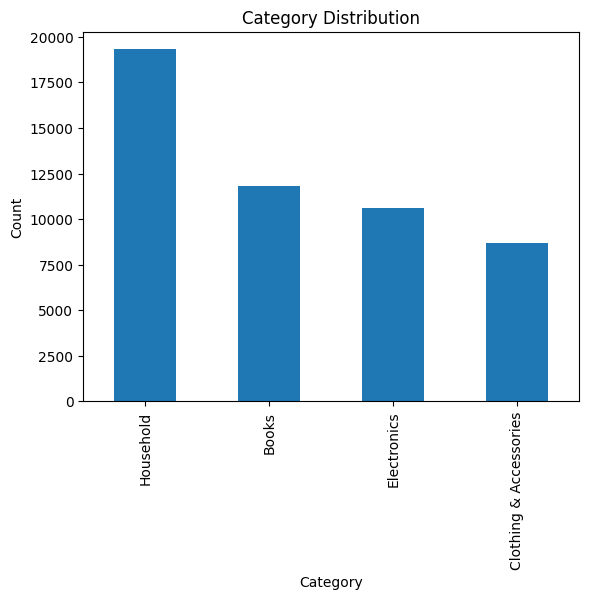

In [9]:
df['category'].value_counts().plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.show()

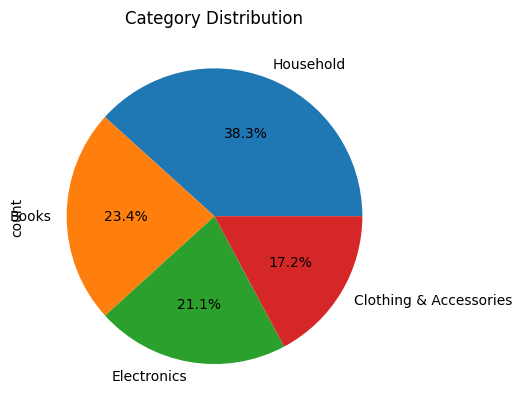

In [10]:
df.category.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Category Distribution')
plt.show()

In [11]:
label_map = {
    'Household': 0,
    'Books': 1,
    'Electronics': 2,
    'Clothing & Accessories': 3
}

df['category_label'] = df['category'].map(label_map)
print(df[['category', 'category_label']].head())

    category  category_label
0  Household               0
1  Household               0
2  Household               0
3  Household               0
4  Household               0


 # 📝 Text Cleaning and Preprocessing (Lowercasing, Punctuation Removal, Stopword Removal, and Lemmatization)

In [12]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Initialize NLTK stopwords and Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)
df['clean_description'] = df['description'].apply(clean_text)

In [14]:
df.head()

,category,description,category_label,clean_description
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",0,saf floral framed painting wood 30 inch x 10 i...
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,0,saf uv textured modern art print framed painti...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",0,saf flower print framed painting synthetic 135...
3,Household,Incredible Gifts India Wooden Happy Birthday U...,0,incredible gift india wooden happy birthday un...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...,0,pitaara box romantic venice canvas painting 6m...


# 📝 Using a Pipeline for TF-IDF and a Model

In [15]:
X = df['description']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LogisticRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

                 Books       0.97      0.96      0.96      3483
Clothing & Accessories       0.98      0.97      0.98      2618
           Electronics       0.97      0.94      0.95      3178
             Household       0.96      0.98      0.97      5848

              accuracy                           0.97     15127
             macro avg       0.97      0.96      0.97     15127
          weighted avg       0.97      0.97      0.97     15127



# 📊 Confusion Matrix:

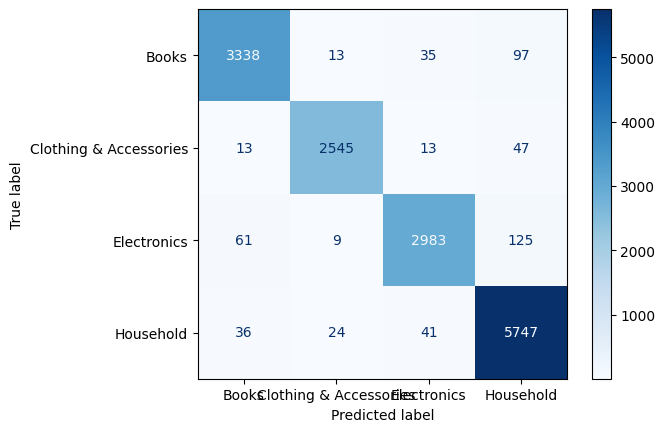

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap='Blues')
plt.show()